In [61]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [190]:
# read in all words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [63]:
len(words)

32033

In [64]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [65]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:]:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [66]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [191]:
# build the dataset: dataset split to training, dev or validation, test

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [192]:
len(words)

32033

In [193]:
n1

25626

In [194]:
n2

28829

In [196]:
n2 - n1

3203

In [67]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        ...,
        [26, 26, 25],
        [26, 25, 26],
        [25, 26, 24]])

In [68]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [69]:
C = torch.randn((27,2)) # 27个字母(a-z + .)，每一个字母用一个二维向量表示

In [70]:
C

tensor([[-1.0844, -0.6055],
        [ 0.4835,  0.3490],
        [-0.1230, -0.9063],
        [-1.4541, -0.2205],
        [-0.1318, -0.7408],
        [-0.9884,  1.6152],
        [-0.7908,  0.0307],
        [-1.5651,  0.2180],
        [-1.0346, -0.5140],
        [-0.1946,  1.0503],
        [-0.9432, -0.2227],
        [-0.1412,  0.1180],
        [ 2.5955, -0.7737],
        [-1.4509, -1.0017],
        [ 1.5971,  0.2601],
        [-1.0643, -0.3373],
        [ 1.2304,  0.4535],
        [-1.3607, -0.1049],
        [ 0.8207, -0.1198],
        [ 0.3462, -0.4811],
        [ 1.3232,  0.7452],
        [-1.8241, -1.0801],
        [-0.5378,  1.0420],
        [-0.3474,  1.0591],
        [ 0.7153,  1.3044],
        [ 1.2123,  0.8952],
        [ 1.0241, -0.9177]])

In [71]:
C[5]

tensor([-0.9884,  1.6152])

In [72]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.9884,  1.6152])

In [73]:
emb = C[X]
emb.shape # 32个样本，每个样本包含3个字母(block_size=3)，每个字母用一个二维向量表示

torch.Size([228146, 3, 2])

In [74]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [75]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape #所有样本的第 1, 2, 3 个字母的向量表示。每个字母由一个二维向量表示

torch.Size([228146, 6])

In [76]:
torch.cat(torch.unbind(emb, 1), dim=1) # cat会创建一个新的张量，效率低很多，使用view

tensor([[-1.0844, -0.6055, -1.0844, -0.6055, -1.0844, -0.6055],
        [-1.0844, -0.6055, -1.0844, -0.6055, -0.9884,  1.6152],
        [-1.0844, -0.6055, -0.9884,  1.6152, -1.4509, -1.0017],
        ...,
        [ 1.0241, -0.9177,  1.0241, -0.9177,  1.2123,  0.8952],
        [ 1.0241, -0.9177,  1.2123,  0.8952,  1.0241, -0.9177],
        [ 1.2123,  0.8952,  1.0241, -0.9177,  0.7153,  1.3044]])

In [77]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [78]:
a.shape

torch.Size([18])

In [79]:
# view更加高效，每个张量中，都有一个底层存储的数组，存储始终以一维向量形式存在
# 调用 view 时，实际是在操作张量的一些属性，这些属性决定如何将一个一维数组解释为一个n维张量
# 调用 view 时，并没有改变，复制，移动或创建任何内存，存储是相同的。实际是底层的存储偏移，步长和形状等发生变化
# https://blog.ezyang.com/2019/05/pytorch-internals/
a.view(3, 3, 2) 

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [80]:
a.view(6, 3)

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17]])

In [81]:
a.storage()

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [197]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [220]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [221]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [222]:
for p in parameters:
    p.requires_grad = True

In [159]:
lre = torch.linspace(-3, 0, 1000) # 生成为线性
lrs = 10**lre # 使学习率变在区间内按指数间隔分布

In [223]:
lri = []
lossi = []
stepi = []

In [234]:
 # 如何确定学习率？
 # 1.确定一个合理范围: 大区间尝试观察损失函数的变化，比如 [-0.001, -1]
 # 2.让学习率在区间内按指数间隔分布
 # 3.追踪学习率和损失函数值的变化。
 # 4.绘制学习率和损失函数之间的变化曲线,可以观察到 -0.1是合适的学习率
 # 5.确定之后，我们使用 -0.1 作为学习率 
 # 6.在 -0.1 学习一段时间后，将学习率进行衰减，比如衰减十分之一

 # 数据集拆分：一般标准拆分为 3 部分，包括
 # (1)训练样本, training set, 80%, 用于优化模型参数
 # (2)开发样本，dev or validation set, 10%, 用于模型所有超参数的开发，隐藏层的大小，嵌入 embdding 的大小
 # (3)测试样本，test set, 10%, 用于最终评估模型的性能，在测试样本上要非常，非常节制地评估损失，
 # 只允许在测试集上很少次数的测试损失，否则，也会有过度拟合的风险。

for i in range(50000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,)) #所有样本中随机取 32 个样本的索引
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2) ---》 X[ix]只获取 X 的 32 行
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    
    # 下面计算等价于 pytorch 提供的 cross_entropy
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    
    # pytorch中有一个函数可以更高效地计算交叉熵损失: torch.nn.functional.cross_entropy
    loss = F.cross_entropy(logits, Ytr[ix]) # 只是小批次的损失，不是所有样本的
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

1.9156464338302612


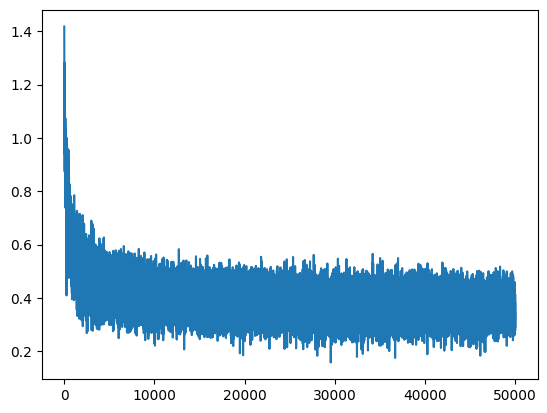

In [225]:
# plt.plot(lri, lossi)
plt.plot(stepi, lossi)

In [235]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1629, grad_fn=<NllLossBackward0>)

In [236]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1974, grad_fn=<NllLossBackward0>)

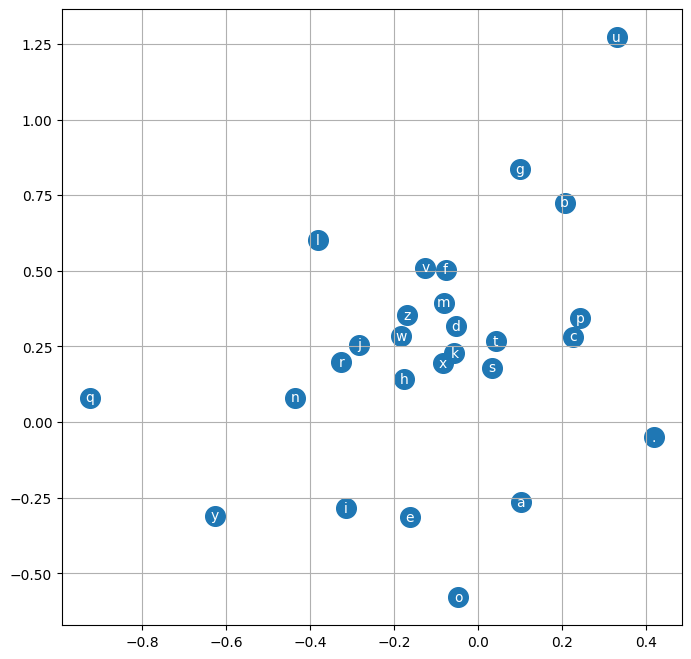

In [219]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [238]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khi.
mili.
taty.
hachas.
emmahnel.
deliah.
jareeigh.
kania.
chaiif.
kaleigh.
ham.
porn.
quint.
sulin.
alia.
bick.
jerri.
jarysi.
